In [1]:
# monitoring_workflow_demo.ipynb
# Environmental Monitoring and Risk Evolution Demo
# Author: Zhiwei Wang

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

np.random.seed(42)

In [2]:
# 1. Generate synthetic monitoring data

n = 300
time = np.arange(n)

# Simulated operational forcing
injection_rate = np.piecewise(
    time,
    [time < 80, (time >= 80) & (time < 180), time >= 180],
    [lambda t: 0.02 * t,
     lambda t: 1.6 + 0.01 * (t - 80),
     lambda t: 2.6 * np.exp(-(t - 180) / 80)]
)

pressure = gaussian_filter1d(injection_rate, sigma=8) + 0.15 * np.random.randn(n)

# Simulated monitoring response
event_rate = (
    0.15
    + 0.6 * pressure
    + 0.015 * np.maximum(time - 120, 0)
    + 0.25 * np.random.randn(n)
)

event_rate = np.clip(event_rate, 0, None)

df = pd.DataFrame({
    "time": time,
    "injection_rate": injection_rate,
    "pressure": pressure,
    "event_rate": event_rate
})

df.head()

,time,injection_rate,pressure,event_rate
0,0,0,0.074507,0.000000
1,1,0,-0.020740,0.000000
2,2,0,0.097153,0.395115
3,3,0,0.228454,0.439665
4,4,0,-0.035123,0.123701


In [3]:
# 2. Compute risk-oriented indicators

df["pressure_smooth"] = gaussian_filter1d(df["pressure"], sigma=5)
df["event_rate_smooth"] = gaussian_filter1d(df["event_rate"], sigma=5)

# First and second derivatives of monitoring response
df["lambda_prime"] = np.gradient(df["event_rate_smooth"])
df["lambda_second"] = np.gradient(df["lambda_prime"])

# Normalized composite risk indicator
def normalize(x):
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-9)

df["risk_indicator"] = (
    0.4 * normalize(df["pressure_smooth"])
    + 0.4 * normalize(df["event_rate_smooth"])
    + 0.2 * normalize(np.maximum(df["lambda_second"], 0))
)

df.head()

,time,injection_rate,pressure,event_rate,pressure_smooth,event_rate_smooth,lambda_prime,lambda_second,risk_indicator
0,0,0,0.074507,0.000000,0.061794,0.206246,0.001614,0.000671,0.063929
1,1,0,-0.020740,0.000000,0.060382,0.207860,0.002285,0.000896,0.070418
2,2,0,0.097153,0.395115,0.057458,0.210816,0.003407,0.000864,0.069338
3,3,0,0.228454,0.439665,0.052864,0.214674,0.004013,0.000318,0.053169
4,4,0,-0.035123,0.123701,0.046444,0.218842,0.004042,-0.000234,0.043305


In [4]:
# 3. Detect warning periods

threshold = df["risk_indicator"].quantile(0.90)
df["warning"] = df["risk_indicator"] >= threshold

warning_times = df.loc[df["warning"], "time"].values

threshold

0.5554296604718949

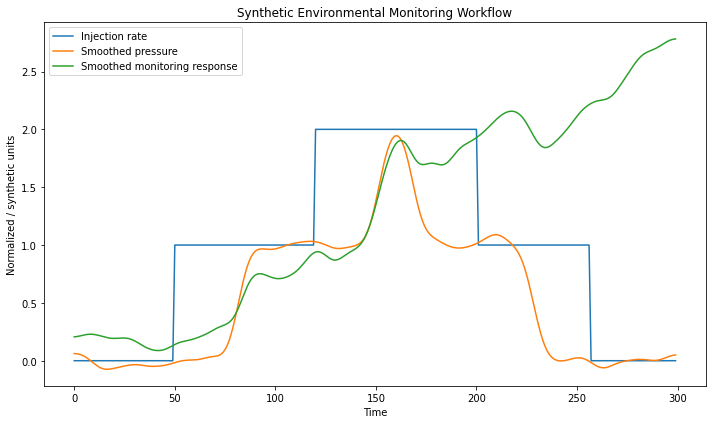

In [5]:
# 4. Plot monitoring variables

plt.figure(figsize=(10, 6))

plt.plot(df["time"], df["injection_rate"], label="Injection rate")
plt.plot(df["time"], df["pressure_smooth"], label="Smoothed pressure")
plt.plot(df["time"], df["event_rate_smooth"], label="Smoothed monitoring response")

plt.xlabel("Time")
plt.ylabel("Normalized / synthetic units")
plt.title("Synthetic Environmental Monitoring Workflow")
plt.legend()
plt.tight_layout()
plt.show()

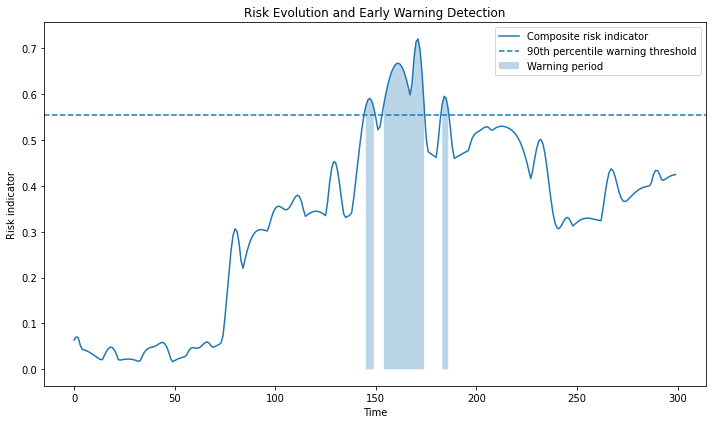

In [6]:
# 5. Plot risk evolution

plt.figure(figsize=(10, 6))

plt.plot(df["time"], df["risk_indicator"], label="Composite risk indicator")
plt.axhline(threshold, linestyle="--", label="90th percentile warning threshold")

plt.fill_between(
    df["time"],
    0,
    df["risk_indicator"],
    where=df["warning"],
    alpha=0.3,
    label="Warning period"
)

plt.xlabel("Time")
plt.ylabel("Risk indicator")
plt.title("Risk Evolution and Early Warning Detection")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# 6. Export results

output_file = "monitoring_risk_indicator_demo.csv"
df.to_csv(output_file, index=False)

output_file

'monitoring_risk_indicator_demo.csv'